In [ ]:
import pandas as pd
sample = pd.DataFrame([
    ["Lebron James", "LAL",35.0,25,7,8,2,1,4,18,10,3],
    ["Player A","BOS",20.0,10,5,2,1,0,1,7,4,2],
    ["Player B","NYK",28.0,15,8,3,1,1,2,14,7,4],
], columns=["Player","Team","MP","PTS","TRB","AST","STL","BLK","TOV","FGA","FGM","PF"])
sample.to_csv("sample_player_stats.csv", index=False)
print("Sample CSV created: sample_player_stats.csv")
sample.head()


Sample CSV created: sample_player_stats.csv


,Player,Team,MP,PTS,TRB,AST,STL,BLK,TOV,FGA,FGM,PF
0,Lebron James,LAL,35.0,25,7,8,2,1,4,18,10,3
1,Player A,BOS,20.0,10,5,2,1,0,1,7,4,2
2,Player B,NYC,28.0,15,8,3,1,1,2,14,7,4


In [ ]:
!pip install --quiet pandas numpy matplotlib seaborn scikit-learn openpyxl
print("Libraries installed.")

Libraries installed.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from google.colab import files
import os
sns.set(style="whitegrid")
os.makedirs("results/figures", exist_ok=True)

def safe_load_csv(filename):
  df = pd.read_csv(filename)
  df = df[df['Player'] != 'Player'] if 'Player' in df.columns else df
  df = df.reset_index(drop=True)
  print(f"Loaded {filename} - shape: {df.shape}")
  display(df.head())
  return df

def ensure_numeric(df, cols):
  for c in cols:
      if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
  return df

In [ ]:
from google.colab import files
print("Select your CSV file to upload (or cancel if you already have sample file).")
uploaded = files.upload()
filename = list(uploaded.keys())[0] if uploaded else None
print("Uploaded:", filename)

Select your CSV file to upload (or cancel if you already have sample file).


Saving 24-25 playoffs - Sheet1.csv to 24-25 playoffs - Sheet1.csv
Uploaded: 24-25 playoffs - Sheet1.csv


In [ ]:
try:
  filename
except NameError:
  filename = None

if not filename:
    filename = "sample_player_stats.csv"

df = safe_load_csv(filename)

Loaded 24-25 playoffs - Sheet1.csv - shape: (219, 15)


,Player,Age,Team,Pos,Games_Played,MP,FGM,FGA,TRB,AST,STL,BLK,TOV,Personal_Fouls,PTS
0,Giannis Antetokounmpo,30,MIL,PF,5,37.6,12.0,19.8,15.4,6.6,1.0,1.0,4.6,2.4,33.0
1,Luka Dončić,25,LAL,PG,5,41.6,9.4,20.8,7.0,5.8,1.0,0.6,4.0,3.2,30.2
2,Shai Gilgeous-Alexander,26,OKC,PG,23,37.0,10.1,21.9,5.3,6.5,1.7,0.9,2.6,2.8,29.9
3,Donovan Mitchell,28,CLE,SG,9,32.0,9.6,21.6,4.7,3.9,1.9,0.3,1.9,2.0,29.6
4,Paolo Banchero,22,ORL,PF,5,39.4,10.8,24.8,8.4,4.2,0.6,0.8,3.0,3.6,29.4


In [ ]:
col_map = {
    'Team':'Team','Tm':'Team',
    'Minutes':'MP','MP':'MP',
    'PTS':'PTS','Points':'PTS',
    'REB':'TRB','TRB':'TRB','REB_per_game':'TRB',
    'AST':'AST','Assists':'AST',
    'STL':'STL','BLK':'BLK','TOV':'TOV',
    'FGA':'FGA','FieldGoalsAttempted':'FGA',
    'FGM':'FGM','FieldGoalsMade':'FGM',
    'PF':'PF','Fouls':'PF'
}

for src, dst in col_map.items():
    if src in df.columns and dst not in df.columns:
        df = df.rename(columns={src:dst})
df = df.rename(columns={
    'G': 'Games_Played',
    'PF': 'Personal_Fouls'
})
desired = [
      'Player','Team','MP',
      'PTS','TRB','AST','STL','BLK','TOV',
      'FGA','FGM','Personal_Fouls',
      'Games_Played','Age','Pos'
  ]

keep = [c for c in desired if c in df.columns]
df = df[keep].copy()

numeric_cols = [c for c in keep if c not in ['Player','Team','Pos']]
df = ensure_numeric(df, numeric_cols)

df = df.dropna(subset=['Player']).reset_index(drop=True)

print("Columns used:", keep)
df.head()


Columns used: ['Player', 'Team', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'FGA', 'FGM', 'Personal_Fouls', 'Games_Played', 'Age', 'Pos']


,Player,Team,MP,PTS,TRB,AST,STL,BLK,TOV,FGA,FGM,Personal_Fouls,Games_Played,Age,Pos
0,Giannis Antetokounmpo,MIL,37.6,33.0,15.4,6.6,1.0,1.0,4.6,19.8,12.0,2.4,5,30,PF
1,Luka Dončić,LAL,41.6,30.2,7.0,5.8,1.0,0.6,4.0,20.8,9.4,3.2,5,25,PG
2,Shai Gilgeous-Alexander,OKC,37.0,29.9,5.3,6.5,1.7,0.9,2.6,21.9,10.1,2.8,23,26,PG
3,Donovan Mitchell,CLE,32.0,29.6,4.7,3.9,1.9,0.3,1.9,21.6,9.6,2.0,9,28,SG
4,Paolo Banchero,ORL,39.4,29.4,8.4,4.2,0.6,0.8,3.0,24.8,10.8,3.6,5,22,PF


In [ ]:
print("=== BEFORE FILTERING ===")
print("Shape:", df.shape)

if 'MP' in df.columns:
  print("Correlation:", df['MP'].corr(df['EFF_per_min']))

In [ ]:
if 'Games_Played' in df.columns:
  df = df[df['Games_Played'] >= 40]
if 'MP' in df.columns:
  df = df[df['MP'] > 10]
df = df.reset_index(drop=True)
print("\n=== AFTER FILTERING===")
print("Shape:", df.shape)

if 'MP' in df.columns:
  print("Correlation:", df['MP'].corr(df['EFF_per_min']))

df.head()

After filtering - shape: (219, 15)


,Player,Team,MP,PTS,TRB,AST,STL,BLK,TOV,FGA,FGM,Personal_Fouls,Games_Played,Age,Pos
0,Giannis Antetokounmpo,MIL,37.6,33.0,15.4,6.6,1.0,1.0,4.6,19.8,12.0,2.4,5,30,PF
1,Luka Dončić,LAL,41.6,30.2,7.0,5.8,1.0,0.6,4.0,20.8,9.4,3.2,5,25,PG
2,Shai Gilgeous-Alexander,OKC,37.0,29.9,5.3,6.5,1.7,0.9,2.6,21.9,10.1,2.8,23,26,PG
3,Donovan Mitchell,CLE,32.0,29.6,4.7,3.9,1.9,0.3,1.9,21.6,9.6,2.0,9,28,SG
4,Paolo Banchero,ORL,39.4,29.4,8.4,4.2,0.6,0.8,3.0,24.8,10.8,3.6,5,22,PF


In [ ]:
pts = df['PTS'] if 'PTS' in df.columns else 0
trb = df['TRB'] if 'TRB' in df.columns else 0
ast = df['AST'] if 'AST' in df.columns else 0
stl = df['STL'] if 'STL' in df.columns else 0
blk = df['BLK'] if 'BLK' in df.columns else 0
tov = df['TOV'] if 'TOV' in df.columns else 0
pf = df['PF'] if 'PF' in df.columns else 0
fga = df['FGA'] if 'FGA' in df.columns else 0
fgm = df['FGM'] if 'FGM' in df.columns else 0

df['MISS'] = fga - fgm

df['EFF'] = (pts + trb + ast + stl + blk) - (df['MISS'] + tov + pf)
df['EFF_per_min'] = df['EFF'] / df['MP']
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['EFF_per_min','MP']).reset_index(drop=True)
df[['Player','Team','MP','EFF','EFF_per_min' ]].head()

,Player,Team,MP,EFF,EFF_per_min
0,Giannis Antetokounmpo,MIL,37.6,44.6,1.186170
1,Luka Dončić,LAL,41.6,29.2,0.701923
2,Shai Gilgeous-Alexander,OKC,37.0,29.9,0.808108
3,Donovan Mitchell,CLE,32.0,26.5,0.828125
4,Paolo Banchero,ORL,39.4,26.4,0.670051


In [ ]:
print("Dataset size:", df.shape)


print("EFF_per_min stats:\n", df['EFF_per_min'].describe().round(3))


if 'MP' in df.columns:
   corr = df['MP'].corr(df['EFF_per_min'])
   print("Pearson correlation MP vs EFF_per_min:", round(corr,3))
else:
  corr = None

Dataset size: (219, 18)
EFF_per_min stats:
 count    219.000
mean       0.465
std        0.272
min       -0.500
25%        0.336
50%        0.459
75%        0.606
max        1.500
Name: EFF_per_min, dtype: float64
Pearson correlation MP vs EFF_per_min: 0.235


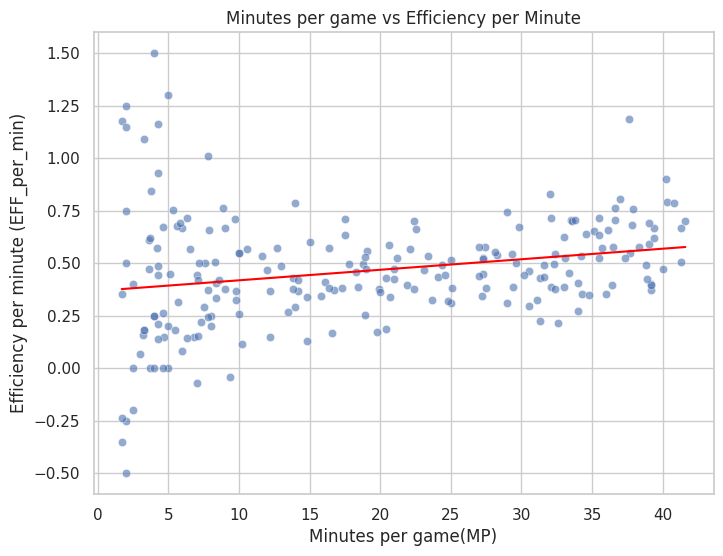

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='MP', y='EFF_per_min', data=df, alpha=0.6)

from sklearn.linear_model import LinearRegression
if 'MP' in df.columns:
  X = df[['MP']].values
  y = df['EFF_per_min'].values
  m = LinearRegression().fit(X, y)

  X_sorted = np.sort(X, axis=0)
  pred = m.predict(X_sorted)

  plt.plot(X_sorted, pred, color='red')

plt.title('Minutes per game vs Efficiency per Minute')
plt.xlabel('Minutes per game(MP)')
plt.ylabel('Efficiency per minute (EFF_per_min)')
plt.grid(True)
plt.savefig('results/figures/mp_vs_efficiency.png', dpi=200)
plt.show()



In [ ]:
for stat in ['PTS','AST','TRB']:
  col = stat + '_per_min'
  if stat in df.columns:
    df[col] = df[stat] / df['MP']

if 'Pos' in df.columns:
  df = pd.get_dummies(df, columns=['Pos'], drop_first=True)

candidate_features = [col for col in df.columns if col in ['MP','PTS_per_min','AST_per_min','TRB_per_min'] or col.startswith('Pos_')]
print("Using features:", candidate_features)

model_df = df.dropna(subset=candidate_features + ['EFF_per_min']).copy()
X = model_df[candidate_features].values
y = model_df['EFF_per_min'].values

if X.shape[0] > 10 and X.shape[1] > 0:
  X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
  model = LinearRegression().fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print("R2:", round(r2_score(y_test, y_pred),3))
  print("MAE:", round(mean_absolute_error(y_test, y_pred),3))
  y_train_pred = model.predict(X_train)
  print("Train R2:", round(r2_score(y_train, y_train_pred),3))
  print("Train MAE:", round(mean_absolute_error(y_train, y_train_pred),3)
  coefs = pd.DataFrame({'feature':candidate_features,'coef':model.coef_})
  display(coefs)
  print("\nIntepretation of coefficients:")
  for i, row in coefs.iterrows():
    print(f"{row['feature']}: {round(row['coef'],3)}")
else:
  print("Not enough data or features for regression")

Using features: ['MP', 'PTS_per_min', 'AST_per_min', 'TRB_per_min']
R2: 0.696
MAE: 0.112


,feature,coef
0,MP,-0.000055
1,PTS_per_min,0.769488
2,AST_per_min,1.031525
3,TRB_per_min,1.025675


In [ ]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary()

In [ ]:
out_xlsx = 'results/project_results.xlsx'

with pd.ExcelWriter(out_xlsx, engine='openpyxl') as writer:
  df.to_excel(writer, sheet_name='cleaned_data', index=False)

  corr_value = corr if 'corr' in globals() else None
  summary = pd.DataFrame({
      'metric' : ['corr_MP_EFFperMin'],
      'value' : [corr_value]
  })

  summary.to_excel(writer, sheet_name='summary', index=False)

  if 'coefs' in globals():
      coefs.to_excel(writer, sheet_name='coefficients', index=False)


print("Saved:", out_xlsx)
files.download(out_xlsx)
files.download('results/figures/mp_vs_efficiency.png')




Saved: results/project_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>